In [1]:
# Phase 1: Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Display Settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# Phase 2: Load Dataset

# Load the dataset
df = pd.read_excel("../datasets/Telco_customer_churn.xlsx")

print("Dataset Loaded Successfully!\n")

# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Display dataset dimensions
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  In

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object


Dataset Shape:
(7043, 33)
Missing Values:



Churn Reason    5174
dtype: int64


Duplicate Rows: 0
Numerical Summary:


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000



Categorical Summary:


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2,20
top,3186-AJIEK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174,192


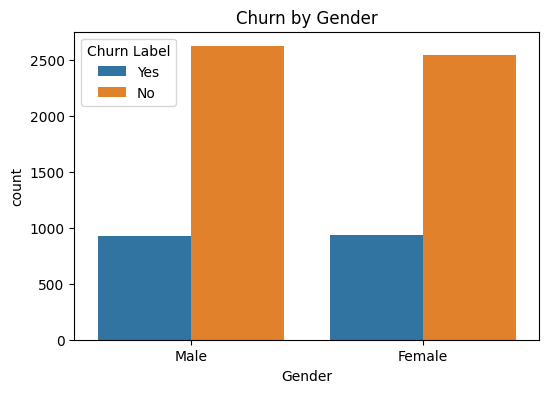

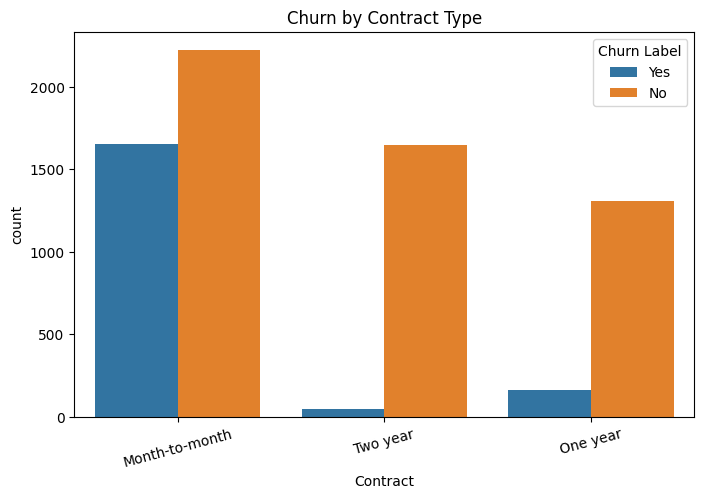

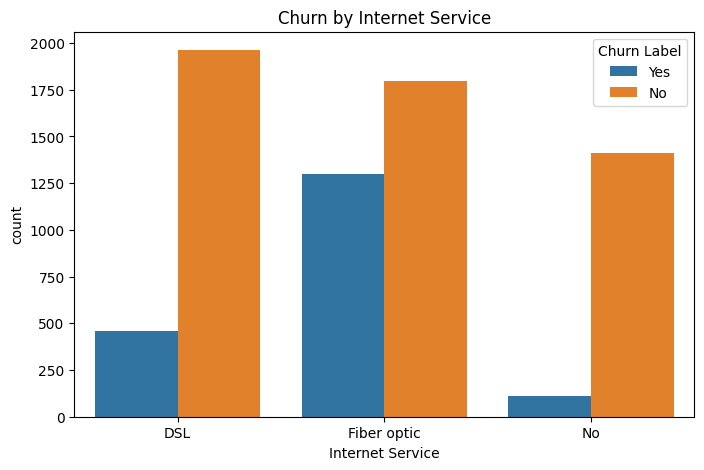

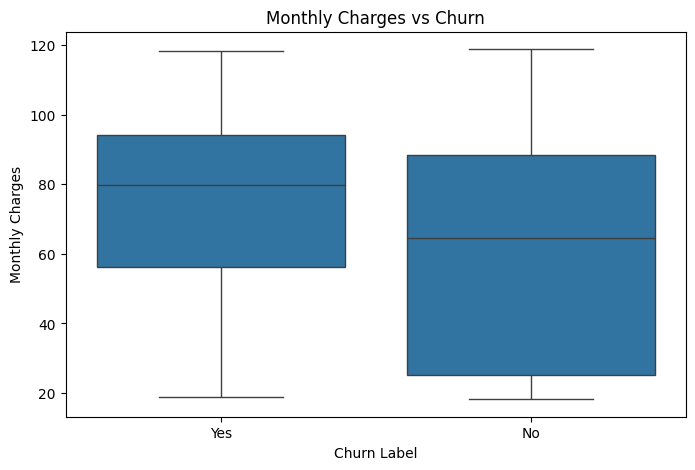

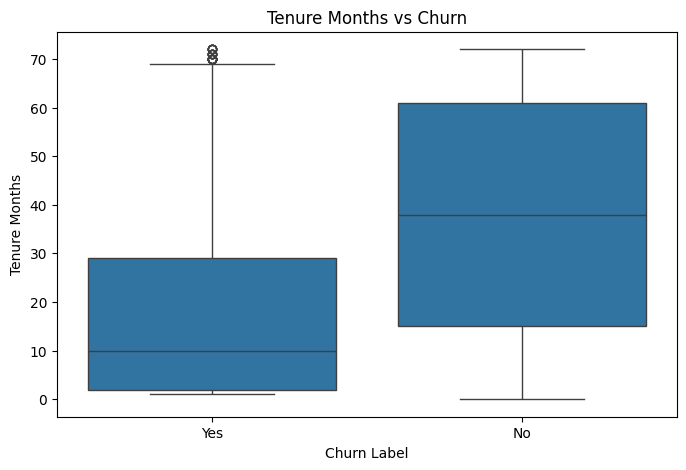

In [4]:

# Phase 3.1: Dataset Overview

# Display dataset information
print("Dataset Information:\n")
df.info()

# Display data types
print("\nData Types:\n")
display(df.dtypes)

# Display dataset dimensions
print("\nDataset Shape:")
print(df.shape)

# Phase 3.2: Missing Values & Duplicates

# Missing values
missing_values = df.isnull().sum()

print("Missing Values:\n")
display(missing_values[missing_values > 0])

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Phase 3.3: Statistical Summary

print("Numerical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include='object'))

# Phase 3.4: Target Variable Distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Churn Label")
plt.title("Churn by Gender")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn Label")
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Internet Service", hue="Churn Label")
plt.title("Churn by Internet Service")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn Label", y="Monthly Charges")
plt.title("Monthly Charges vs Churn")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn Label", y="Tenure Months")
plt.title("Tenure Months vs Churn")
plt.show()